In [ ]:
# Homework 2
# Gabriel Almodovar
# Student ID: 801296062


In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from google.colab import drive
    drive.mount('/content/drive')
    file_path = '/content/drive/My Drive/Courses/Intro-to-ML/Datasets/Housing.csv'
except ImportError:
    file_path = 'upload/Housing.csv'


Mounted at /content/drive


In [2]:
Housing = pd.DataFrame(pd.read_csv(file_path))
Housing.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
Housing.isnull().sum()*100/Housing.shape[0]


,0
price,0.0
area,0.0
bedrooms,0.0
bathrooms,0.0
stories,0.0
mainroad,0.0
guestroom,0.0
basement,0.0
hotwaterheating,0.0
airconditioning,0.0


In [4]:
# CONVERT YES/NO VARIABLES TO 1/0
yes_no_columns = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

Housing[yes_no_columns] = Housing[yes_no_columns].apply(
    lambda column: column.map({'yes': 1, 'no': 0})
)

# CREATE THE SAME 80/20 SPLIT FOR EVERY PROBLEM
np.random.seed(42)
indices = np.random.permutation(len(Housing))
training_size = int(0.80 * len(Housing))

training_indices = indices[:training_size]
validation_indices = indices[training_size:]

Y = Housing[['price']].to_numpy(dtype=float)
Y_train = Y[training_indices]
Y_validation = Y[validation_indices]

print("Training samples:", len(training_indices))
print("Validation samples:", len(validation_indices))


Training samples: 436
Validation samples: 109


In [5]:
# FUNCTIONS USED THROUGHOUT THE HOMEWORK
def gradient_descent(X_train, Y_train, X_validation, Y_validation,
                     learning_rate, max_iterations):

    m = len(Y_train)

    X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
    X_validation_b = np.c_[np.ones((len(X_validation), 1)), X_validation]

    theta = np.zeros((X_train_b.shape[1], 1))
    train_loss = []
    validation_loss = []

    for iteration in range(max_iterations):

        predictions = X_train_b.dot(theta)
        errors = predictions - Y_train

        gradients = (2 / m) * X_train_b.T.dot(errors)
        theta -= learning_rate * gradients

        training_mse = (1 / m) * np.sum(
            np.square(X_train_b.dot(theta) - Y_train)
        )

        validation_mse = (1 / len(Y_validation)) * np.sum(
            np.square(X_validation_b.dot(theta) - Y_validation)
        )

        train_loss.append(training_mse)
        validation_loss.append(validation_mse)

    return theta, train_loss, validation_loss


def gradient_descent_l2(X_train, Y_train, X_validation, Y_validation,
                        learning_rate, max_iterations, penalty):

    m = len(Y_train)

    X_train_b = np.c_[np.ones((len(X_train), 1)), X_train]
    X_validation_b = np.c_[np.ones((len(X_validation), 1)), X_validation]

    theta = np.zeros((X_train_b.shape[1], 1))
    train_loss = []
    validation_loss = []

    for iteration in range(max_iterations):

        predictions = X_train_b.dot(theta)
        errors = predictions - Y_train

        gradients = (2 / m) * X_train_b.T.dot(errors)

        # DO NOT APPLY THE PENALTY TO THE INTERCEPT
        gradients[1:] += (2 * penalty / m) * theta[1:]

        theta -= learning_rate * gradients

        training_mse = (1 / m) * np.sum(
            np.square(X_train_b.dot(theta) - Y_train)
        )

        training_penalty = (penalty / m) * np.sum(
            np.square(theta[1:])
        )

        # EVALUATION LOSS DOES NOT INCLUDE THE PARAMETER PENALTY
        validation_mse = (1 / len(Y_validation)) * np.sum(
            np.square(X_validation_b.dot(theta) - Y_validation)
        )

        train_loss.append(training_mse + training_penalty)
        validation_loss.append(validation_mse)

    return theta, train_loss, validation_loss


def standardize_input(X_train, X_validation):

    training_mean = np.mean(X_train, axis=0)
    training_std = np.std(X_train, axis=0)
    training_std[training_std == 0] = 1

    X_train_standardized = (X_train - training_mean) / training_std
    X_validation_standardized = (
        X_validation - training_mean
    ) / training_std

    return X_train_standardized, X_validation_standardized


def normalize_input(X_train, X_validation):

    training_min = np.min(X_train, axis=0)
    training_range = np.max(X_train, axis=0) - training_min
    training_range[training_range == 0] = 1

    X_train_normalized = (X_train - training_min) / training_range
    X_validation_normalized = (
        X_validation - training_min
    ) / training_range

    return X_train_normalized, X_validation_normalized


def r_squared(Y_actual, Y_prediction):

    residual_sum = np.sum(np.square(Y_actual - Y_prediction))
    total_sum = np.sum(np.square(Y_actual - np.mean(Y_actual)))

    return 1 - residual_sum / total_sum


def parameter_table(feature_names, theta):

    names = ['theta_0'] + feature_names
    return pd.DataFrame({
        'Parameter': names,
        'Value': theta[:, 0]
    })


In [6]:
# TEST THE REQUIRED LEARNING-RATE RANGE ON RAW INPUTS
features_1a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X_1a = Housing[features_1a].to_numpy(dtype=float)

X_train_1a = X_1a[training_indices]
X_validation_1a = X_1a[validation_indices]

learning_rates_to_test = [0.10, 0.05, 0.01]

for test_rate in learning_rates_to_test:

    X_test_b = np.c_[np.ones((len(X_train_1a), 1)), X_train_1a]
    theta_test = np.zeros((X_test_b.shape[1], 1))
    result = "Stable"

    with np.errstate(over='ignore', invalid='ignore'):
        for iteration in range(100):
            errors_test = X_test_b.dot(theta_test) - Y_train
            gradients_test = (2 / len(Y_train)) * X_test_b.T.dot(errors_test)
            theta_test -= test_rate * gradients_test

            if not np.all(np.isfinite(theta_test)):
                result = "Diverged"
                break

            if np.max(np.abs(theta_test)) > 1e100:
                result = "Diverged"
                break

    print("Learning rate:", test_rate, "-", result)


Learning rate: 0.1 - Diverged
Learning rate: 0.05 - Diverged
Learning rate: 0.01 - Diverged


In [7]:
# PROBLEM 1.A
learning_rate_1a = 0.00000001
max_iterations_1a = 20000

theta_1a, train_loss_1a, validation_loss_1a = gradient_descent(
    X_train_1a,
    Y_train,
    X_validation_1a,
    Y_validation,
    learning_rate_1a,
    max_iterations_1a
)

print("Problem 1.a final training MSE:", train_loss_1a[-1])
print("Problem 1.a final validation MSE:", validation_loss_1a[-1])
parameter_table(features_1a, theta_1a)


Problem 1.a final training MSE: 3428442590030.278
Problem 1.a final validation MSE: 3028269454454.3467


,Parameter,Value
0,theta_0,149.392978
1,area,842.449425
2,bedrooms,566.632925
3,bathrooms,318.913632
4,stories,500.937892
5,parking,115.324559


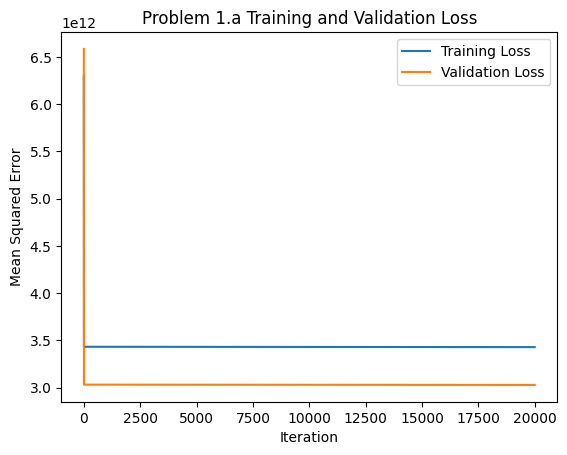

In [8]:
# TRAINING AND VALIDATION LOSS, PROBLEM 1.A
plt.plot(train_loss_1a, label="Training Loss")
plt.plot(validation_loss_1a, label="Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.title("Problem 1.a Training and Validation Loss")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.show()


In [9]:
# PROBLEM 1.B
features_1b = [
    'area', 'bedrooms', 'bathrooms', 'stories',
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning',
    'parking', 'prefarea'
]

X_1b = Housing[features_1b].to_numpy(dtype=float)
X_train_1b = X_1b[training_indices]
X_validation_1b = X_1b[validation_indices]

learning_rate_1b = 0.00000001
max_iterations_1b = 20000

theta_1b, train_loss_1b, validation_loss_1b = gradient_descent(
    X_train_1b,
    Y_train,
    X_validation_1b,
    Y_validation,
    learning_rate_1b,
    max_iterations_1b
)

print("Problem 1.b final training MSE:", train_loss_1b[-1])
print("Problem 1.b final validation MSE:", validation_loss_1b[-1])
parameter_table(features_1b, theta_1b)


Problem 1.b final training MSE: 3428160703197.1357
Problem 1.b final validation MSE: 3028069365973.0215


,Parameter,Value
0,theta_0,149.388768
1,area,842.411256
2,bedrooms,566.619589
3,bathrooms,318.907286
4,stories,500.927971
5,mainroad,131.351424
6,guestroom,61.599894
7,basement,97.331263
8,hotwaterheating,16.698819
9,airconditioning,141.460585


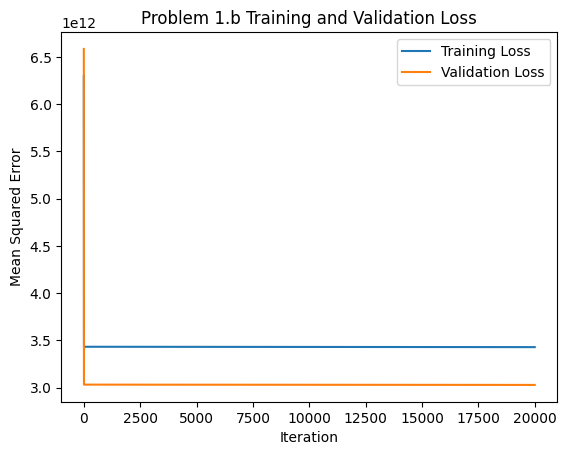

In [10]:
# TRAINING AND VALIDATION LOSS, PROBLEM 1.B
plt.plot(train_loss_1b, label="Training Loss")
plt.plot(validation_loss_1b, label="Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.title("Problem 1.b Training and Validation Loss")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.show()


## Problem 2: Input normalization and standardization

Only the input variables are scaled. The housing price output remains in its original units. Scaling parameters are calculated from the training set and then applied to the validation set to avoid data leakage.


In [11]:
# PROBLEM 2.A
X_train_2a_standardized, X_validation_2a_standardized = standardize_input(
    X_train_1a, X_validation_1a
)

X_train_2a_normalized, X_validation_2a_normalized = normalize_input(
    X_train_1a, X_validation_1a
)

learning_rate_2a = 0.05
max_iterations_2a = 5000

theta_2a_standardized, train_loss_2a_standardized, validation_loss_2a_standardized = gradient_descent(
    X_train_2a_standardized,
    Y_train,
    X_validation_2a_standardized,
    Y_validation,
    learning_rate_2a,
    max_iterations_2a
)

theta_2a_normalized, train_loss_2a_normalized, validation_loss_2a_normalized = gradient_descent(
    X_train_2a_normalized,
    Y_train,
    X_validation_2a_normalized,
    Y_validation,
    learning_rate_2a,
    max_iterations_2a
)

print("Standardized parameters, Problem 2.a")
print(parameter_table(features_1a, theta_2a_standardized).to_string(index=False))
print("\nNormalized parameters, Problem 2.a")
print(parameter_table(features_1a, theta_2a_normalized).to_string(index=False))


Standardized parameters, Problem 2.a
Parameter        Value
  theta_0 4.788866e+06
     area 7.086116e+05
 bedrooms 1.295346e+05
bathrooms 5.679248e+05
  stories 5.216670e+05
  parking 3.163006e+05

Normalized parameters, Problem 2.a
Parameter        Value
  theta_0 2.197270e+06
     area 4.652560e+06
 bedrooms 8.817497e+05
bathrooms 2.229130e+06
  stories 1.813784e+06
  parking 1.102252e+06


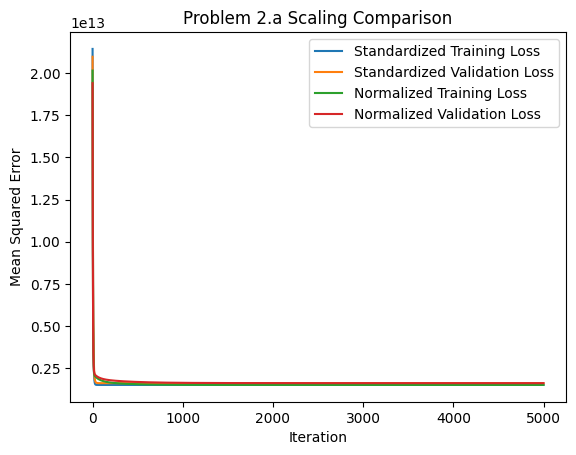

In [12]:
# TRAINING AND VALIDATION LOSS, PROBLEM 2.A
plt.plot(train_loss_2a_standardized, label="Standardized Training Loss")
plt.plot(validation_loss_2a_standardized, label="Standardized Validation Loss")
plt.plot(train_loss_2a_normalized, label="Normalized Training Loss")
plt.plot(validation_loss_2a_normalized, label="Normalized Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.title("Problem 2.a Scaling Comparison")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.show()


In [14]:
# COMPARE PROBLEM 2.A WITH PROBLEM 1.A
X_train_1a_b = np.c_[np.ones((len(X_train_1a), 1)), X_train_1a]
X_validation_1a_b = np.c_[
    np.ones((len(X_validation_1a), 1)), X_validation_1a
]

X_train_2a_standardized_b = np.c_[
    np.ones((len(X_train_2a_standardized), 1)),
    X_train_2a_standardized
]

X_validation_2a_standardized_b = np.c_[
    np.ones((len(X_validation_2a_standardized), 1)),
    X_validation_2a_standardized
]

X_train_2a_normalized_b = np.c_[
    np.ones((len(X_train_2a_normalized), 1)),
    X_train_2a_normalized
]

X_validation_2a_normalized_b = np.c_[
    np.ones((len(X_validation_2a_normalized), 1)),
    X_validation_2a_normalized
]

prediction_train_1a = X_train_1a_b.dot(theta_1a)
prediction_validation_1a = X_validation_1a_b.dot(theta_1a)

prediction_train_2a_standardized = X_train_2a_standardized_b.dot(
    theta_2a_standardized
)

prediction_2a_standardized = X_validation_2a_standardized_b.dot(
    theta_2a_standardized
)

prediction_train_2a_normalized = X_train_2a_normalized_b.dot(
    theta_2a_normalized
)

prediction_2a_normalized = X_validation_2a_normalized_b.dot(
    theta_2a_normalized
)

comparison_2a = pd.DataFrame({
    'Method': ['No Scaling', 'Standardization', 'Normalization'],
    'Training MSE': [
        train_loss_1a[-1],
        train_loss_2a_standardized[-1],
        train_loss_2a_normalized[-1]
    ],
    'Validation MSE': [
        validation_loss_1a[-1],
        validation_loss_2a_standardized[-1],
        validation_loss_2a_normalized[-1]
    ],
    'Training R-Squared': [
        r_squared(Y_train, prediction_train_1a),
        r_squared(Y_train, prediction_train_2a_standardized),
        r_squared(Y_train, prediction_train_2a_normalized)
    ],
    'Validation R-Squared': [
        r_squared(Y_validation, prediction_validation_1a),
        r_squared(Y_validation, prediction_2a_standardized),
        r_squared(Y_validation, prediction_2a_normalized)
    ]
})

comparison_2a


,Method,Training MSE,Validation MSE,Training R-Squared,Validation R-Squared
0,No Scaling,3.428443e+12,3.028269e+12,0.016146,0.137738
1,Standardization,1.515074e+12,1.619322e+12,0.565222,0.538918
2,Normalization,1.515074e+12,1.619332e+12,0.565222,0.538915


In [15]:
# PROBLEM 2.B
X_train_2b_standardized, X_validation_2b_standardized = standardize_input(
    X_train_1b, X_validation_1b
)

X_train_2b_normalized, X_validation_2b_normalized = normalize_input(
    X_train_1b, X_validation_1b
)

learning_rate_2b = 0.05
max_iterations_2b = 5000

theta_2b_standardized, train_loss_2b_standardized, validation_loss_2b_standardized = gradient_descent(
    X_train_2b_standardized,
    Y_train,
    X_validation_2b_standardized,
    Y_validation,
    learning_rate_2b,
    max_iterations_2b
)

theta_2b_normalized, train_loss_2b_normalized, validation_loss_2b_normalized = gradient_descent(
    X_train_2b_normalized,
    Y_train,
    X_validation_2b_normalized,
    Y_validation,
    learning_rate_2b,
    max_iterations_2b
)

print("Standardized parameters, Problem 2.b")
print(parameter_table(features_1b, theta_2b_standardized).to_string(index=False))
print("\nNormalized parameters, Problem 2.b")
print(parameter_table(features_1b, theta_2b_normalized).to_string(index=False))


Standardized parameters, Problem 2.b
      Parameter        Value
        theta_0 4.788866e+06
           area 5.469615e+05
       bedrooms 1.147387e+05
      bathrooms 5.012905e+05
        stories 4.065366e+05
       mainroad 1.642244e+05
      guestroom 1.046142e+05
       basement 1.387132e+05
hotwaterheating 1.633031e+05
airconditioning 4.534752e+05
        parking 2.380565e+05
       prefarea 3.052128e+05

Normalized parameters, Problem 2.b
      Parameter        Value
        theta_0 1.630640e+06
           area 3.590795e+06
       bedrooms 7.815890e+05
      bathrooms 1.967550e+06
        stories 1.413326e+06
       mainroad 4.872760e+05
      guestroom 2.743540e+05
       basement 2.924103e+05
hotwaterheating 8.208339e+05
airconditioning 9.769224e+05
        parking 8.296140e+05
       prefarea 7.209983e+05


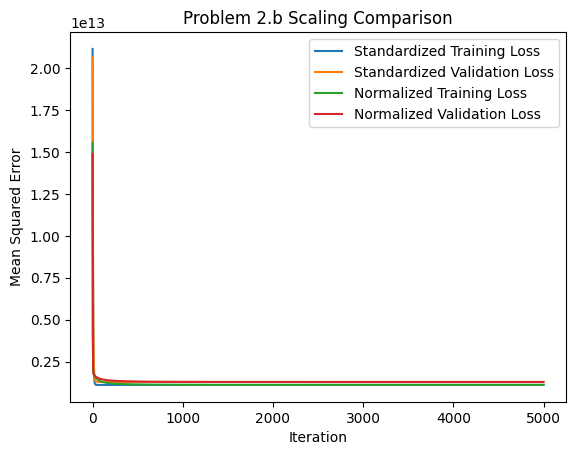

In [16]:
# TRAINING AND VALIDATION LOSS, PROBLEM 2.B
plt.plot(train_loss_2b_standardized, label="Standardized Training Loss")
plt.plot(validation_loss_2b_standardized, label="Standardized Validation Loss")
plt.plot(train_loss_2b_normalized, label="Normalized Training Loss")
plt.plot(validation_loss_2b_normalized, label="Normalized Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.title("Problem 2.b Scaling Comparison")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.show()


In [17]:
# COMPARE PROBLEM 2.B WITH PROBLEM 1.B
X_train_1b_b = np.c_[np.ones((len(X_train_1b), 1)), X_train_1b]
X_validation_1b_b = np.c_[
    np.ones((len(X_validation_1b), 1)), X_validation_1b
]

X_train_2b_standardized_b = np.c_[
    np.ones((len(X_train_2b_standardized), 1)),
    X_train_2b_standardized
]

X_validation_2b_standardized_b = np.c_[
    np.ones((len(X_validation_2b_standardized), 1)),
    X_validation_2b_standardized
]

X_train_2b_normalized_b = np.c_[
    np.ones((len(X_train_2b_normalized), 1)),
    X_train_2b_normalized
]

X_validation_2b_normalized_b = np.c_[
    np.ones((len(X_validation_2b_normalized), 1)),
    X_validation_2b_normalized
]

prediction_train_1b = X_train_1b_b.dot(theta_1b)
prediction_validation_1b = X_validation_1b_b.dot(theta_1b)

prediction_train_2b_standardized = X_train_2b_standardized_b.dot(
    theta_2b_standardized
)

prediction_2b_standardized = X_validation_2b_standardized_b.dot(
    theta_2b_standardized
)

prediction_train_2b_normalized = X_train_2b_normalized_b.dot(
    theta_2b_normalized
)

prediction_2b_normalized = X_validation_2b_normalized_b.dot(
    theta_2b_normalized
)

comparison_2b = pd.DataFrame({
    'Method': ['No Scaling', 'Standardization', 'Normalization'],
    'Training MSE': [
        train_loss_1b[-1],
        train_loss_2b_standardized[-1],
        train_loss_2b_normalized[-1]
    ],
    'Validation MSE': [
        validation_loss_1b[-1],
        validation_loss_2b_standardized[-1],
        validation_loss_2b_normalized[-1]
    ],
    'Training R-Squared': [
        r_squared(Y_train, prediction_train_1b),
        r_squared(Y_train, prediction_train_2b_standardized),
        r_squared(Y_train, prediction_train_2b_normalized)
    ],
    'Validation R-Squared': [
        r_squared(Y_validation, prediction_validation_1b),
        r_squared(Y_validation, prediction_2b_standardized),
        r_squared(Y_validation, prediction_2b_normalized)
    ]
})

comparison_2b


,Method,Training MSE,Validation MSE,Training R-Squared,Validation R-Squared
0,No Scaling,3.428161e+12,3.028069e+12,0.016226,0.137794
1,Standardization,1.113326e+12,1.288760e+12,0.680511,0.633041
2,Normalization,1.113326e+12,1.288780e+12,0.680511,0.633036


In [18]:
# PROBLEM 3.A
if validation_loss_2a_standardized[-1] <= validation_loss_2a_normalized[-1]:
    best_scaling_3a = 'Standardization'
    X_train_3a = X_train_2a_standardized
    X_validation_3a = X_validation_2a_standardized
    problem_2a_best_validation = validation_loss_2a_standardized[-1]
else:
    best_scaling_3a = 'Normalization'
    X_train_3a = X_train_2a_normalized
    X_validation_3a = X_validation_2a_normalized
    problem_2a_best_validation = validation_loss_2a_normalized[-1]

learning_rate_3a = 0.05
max_iterations_3a = 5000
penalty_3a = 100

theta_3a, train_loss_3a, validation_loss_3a = gradient_descent_l2(
    X_train_3a,
    Y_train,
    X_validation_3a,
    Y_validation,
    learning_rate_3a,
    max_iterations_3a,
    penalty_3a
)

print("Best scaling method for Problem 3.a:", best_scaling_3a)
print("Problem 2.a best validation MSE:", problem_2a_best_validation)
print("Problem 3.a validation MSE:", validation_loss_3a[-1])
parameter_table(features_1a, theta_3a)


Best scaling method for Problem 3.a: Standardization
Problem 2.a best validation MSE: 1619321836117.5254
Problem 3.a validation MSE: 1643658783833.6365


,Parameter,Value
0,theta_0,4.788866e+06
1,area,5.936415e+05
2,bedrooms,1.717713e+05
3,bathrooms,4.892886e+05
4,stories,4.373645e+05
5,parking,2.987349e+05


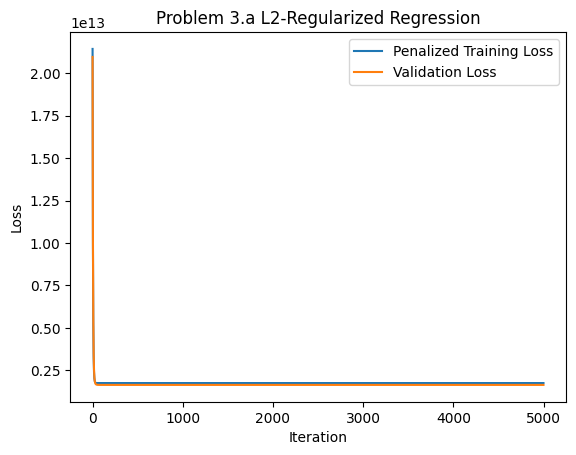

In [19]:
# TRAINING AND VALIDATION LOSS, PROBLEM 3.A
plt.plot(train_loss_3a, label="Penalized Training Loss")
plt.plot(validation_loss_3a, label="Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Problem 3.a L2-Regularized Regression")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.show()


In [20]:
# PROBLEM 3.B
if validation_loss_2b_standardized[-1] <= validation_loss_2b_normalized[-1]:
    best_scaling_3b = 'Standardization'
    X_train_3b = X_train_2b_standardized
    X_validation_3b = X_validation_2b_standardized
    problem_2b_best_validation = validation_loss_2b_standardized[-1]
else:
    best_scaling_3b = 'Normalization'
    X_train_3b = X_train_2b_normalized
    X_validation_3b = X_validation_2b_normalized
    problem_2b_best_validation = validation_loss_2b_normalized[-1]

learning_rate_3b = 0.05
max_iterations_3b = 5000
penalty_3b = 100

theta_3b, train_loss_3b, validation_loss_3b = gradient_descent_l2(
    X_train_3b,
    Y_train,
    X_validation_3b,
    Y_validation,
    learning_rate_3b,
    max_iterations_3b,
    penalty_3b
)

print("Best scaling method for Problem 3.b:", best_scaling_3b)
print("Problem 2.b best validation MSE:", problem_2b_best_validation)
print("Problem 3.b validation MSE:", validation_loss_3b[-1])
parameter_table(features_1b, theta_3b)


Best scaling method for Problem 3.b: Standardization
Problem 2.b best validation MSE: 1288760073344.5854
Problem 3.b validation MSE: 1280169181329.7368


,Parameter,Value
0,theta_0,4.788866e+06
1,area,4.692242e+05
2,bedrooms,1.521811e+05
3,bathrooms,4.353661e+05
4,stories,3.515648e+05
5,mainroad,1.666725e+05
6,guestroom,1.118637e+05
7,basement,1.166736e+05
8,hotwaterheating,1.309423e+05
9,airconditioning,3.988856e+05


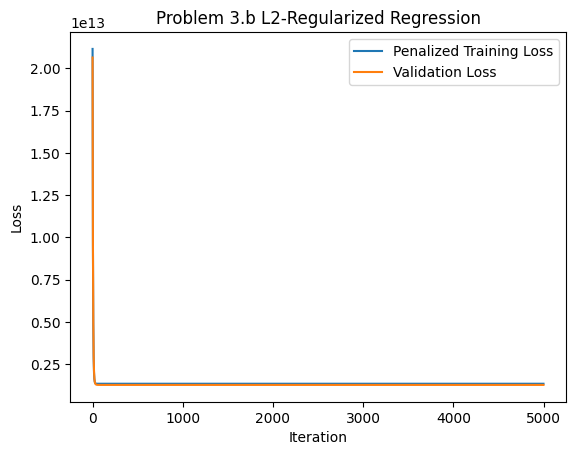

In [21]:
# TRAINING AND VALIDATION LOSS, PROBLEM 3.B
plt.plot(train_loss_3b, label="Penalized Training Loss")
plt.plot(validation_loss_3b, label="Validation Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Problem 3.b L2-Regularized Regression")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.show()


In [22]:
# FINAL COMPARISON
final_comparison = pd.DataFrame({
    'Problem': ['2.a', '3.a', '2.b', '3.b'],
    'Method': [
        best_scaling_3a,
        best_scaling_3a + ' with L2',
        best_scaling_3b,
        best_scaling_3b + ' with L2'
    ],
    'Validation MSE': [
        problem_2a_best_validation,
        validation_loss_3a[-1],
        problem_2b_best_validation,
        validation_loss_3b[-1]
    ]
})

final_comparison


,Problem,Method,Validation MSE
0,2.a,Standardization,1.619322e+12
1,3.a,Standardization with L2,1.643659e+12
2,2.b,Standardization,1.288760e+12
3,3.b,Standardization with L2,1.280169e+12
